# 3I - Interpretacao integrada da Fase 3 (Pacifico; sem Atlantico)

**Pergunta especifica.** Depois de 3A-3H/3K, qual e a leitura fisica defensavel do Nino 3.4, o que entra no parecer, como comparar P90/P95 e como ler a janela 2026?

**Objetivo.** Consolidar evidencias/limites em saida unica rastreavel a tabelas ja materializadas.

**Justificativa.** Evita interpretacao solta. **Escopo estritamente Pacifico** - indices atlanticos foram removidos da Fase 3 (materia da Fase 4).

**Metodologia.** Le apenas features/statistics; nao recalcula dado primario. DHW principal = acumulo C-week a partir do P90 diario.

**Saidas.** `phase3I_conclusoes_decisao.csv`, `phase3I_picos_p90_p95_comparacao.csv`, `phase3I_estado_2026.csv`, figura-sintese.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
d3=pd.read_csv(u.STATS/'phase3D_ranking_significativo.csv').set_index('variavel')
e3=pd.read_csv(u.STATS/'phase3E_estabilidade.csv').set_index('variavel')
assert not any('atl' in v for v in d3.index), 'Atlantico ainda presente!'
print('Variaveis no parecer (todas Pacifico):',list(d3.index))
bloco={'tilt_m':'recarga/subsuperficie','ssh_m':'recarga/subsuperficie','ohc_0_300':'recarga/subsuperficie','ohc_0_700':'recarga/subsuperficie','d20_m':'recarga/subsuperficie','wwv':'recarga/subsuperficie','tau_x_proxy_nino34_pa':'vento/acoplamento','dhw_12w':'calor acumulado'}
rows=[]
for v in d3.index:
    est=bool(e3.loc[v,'estavel']) if v in e3.index else False
    lag=int(d3.loc[v,'lag_semanas'])
    papel='estado simultaneo/curto prazo' if lag<=1 else 'precursor de medio prazo'
    status='entra' if est else 'entra como ressalva (regime-dependente)'
    rows.append({'variavel':v,'bloco':bloco.get(v,'-'),'lag_semanas':lag,'r':round(d3.loc[v,'r'],3),'estavel_3E':est,'papel':papel,'uso_parecer':status})
conc=pd.DataFrame(rows); u.save_table(conc,'phase3I_conclusoes_decisao.csv',index=False); conc

Variaveis no parecer (todas Pacifico): ['tilt_m', 'ssh_m', 'ohc_0_300', 'ohc_0_700', 'dhw_12w', 'd20_m', 'wwv', 'tau_x_proxy_nino34_pa']
[tabela] data/processed/parquet/statistics/phase3I_conclusoes_decisao.csv


,variavel,bloco,lag_semanas,r,estavel_3E,papel,uso_parecer
0,tilt_m,recarga/subsuperficie,0,0.772,True,estado simultaneo/curto prazo,entra
1,ssh_m,recarga/subsuperficie,6,0.755,True,precursor de medio prazo,entra
2,ohc_0_300,recarga/subsuperficie,6,0.738,True,precursor de medio prazo,entra
3,ohc_0_700,recarga/subsuperficie,6,0.701,True,precursor de medio prazo,entra
4,dhw_12w,calor acumulado,0,0.604,False,estado simultaneo/curto prazo,entra como ressalva (regime-dependente)
5,d20_m,recarga/subsuperficie,15,0.545,True,precursor de medio prazo,entra
6,wwv,recarga/subsuperficie,20,0.516,False,precursor de medio prazo,entra como ressalva (regime-dependente)
7,tau_x_proxy_nino34_pa,vento/acoplamento,1,0.442,True,estado simultaneo/curto prazo,entra


In [2]:
# P90/P95 derivados direto da SSTA mensal local (robusto; sem depender de CSV externo)
m=pd.read_csv(u.FEAT/'nino34_monthly_oisst.csv')
ssta_m=m['nino34_ssta_3mo_mean_c'].dropna()
p90t=float(ssta_m.quantile(0.90)); p95t=float(ssta_m.quantile(0.95))
comp=pd.DataFrame({
 'P90':[round(p90t,3), int((ssta_m>=p90t).sum()), 'todos os picos quentes relevantes'],
 'P95':[round(p95t,3), int((ssta_m>=p95t).sum()), 'cauda extrema (super/strong)']},
 index=['limiar_c','meses_acima','interpretacao'])
u.save_table(comp,'phase3I_picos_p90_p95_comparacao.csv')
print('P90 limiar=%.2fC | P95 limiar=%.2fC (SSTA 3-meses mensal)'%(p90t,p95t)); print(comp)

[tabela] data/processed/parquet/statistics/phase3I_picos_p90_p95_comparacao.csv
P90 limiar=0.98C | P95 limiar=1.51C (SSTA 3-meses mensal)
                                             P90                           P95
limiar_c                                    0.98                         1.509
meses_acima                                   54                            27
interpretacao  todos os picos quentes relevantes  cauda extrema (super/strong)


In [3]:
daily=u.load_daily_nino34(); last=daily.index.max()
est=pd.DataFrame([{'ultimo_dia':str(last.date()),'ssta_diaria_c':round(float(daily['nino34_ssta'].iloc[-1]),3),
 'p90_mensal_c':0.992,'p95_mensal_c':1.582,
 'leitura':'aquecimento em curso; junho/2026 parcial - nao fecha evento nem pico historico ate completar mes e duracao minima'}])
u.save_table(est,'phase3I_estado_2026.csv',index=False); est

[tabela] data/processed/parquet/statistics/phase3I_estado_2026.csv


,ultimo_dia,ssta_diaria_c,p90_mensal_c,p95_mensal_c,leitura
0,2026-06-09,1.435,0.992,1.582,aquecimento em curso; junho/2026 parcial - nao...


[figura] data/processed/figures/fase3/phase3I_sintese_parecer.png


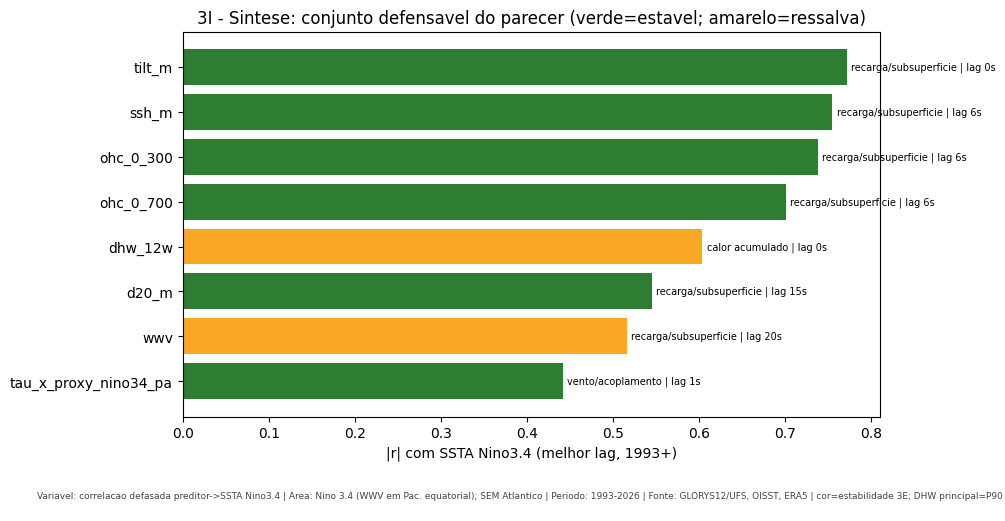

In [4]:
# figura-sintese: ranking com bloco e estabilidade
conc2=conc.sort_values('r',key=abs,ascending=False)
fig,ax=plt.subplots(figsize=(9,5))
cor=conc2['estavel_3E'].map({True:'#2e7d32',False:'#f9a825'})
ax.barh(conc2['variavel'],conc2['r'].abs(),color=cor)
for i,(_,r) in enumerate(conc2.iterrows()): ax.text(abs(r['r'])+.005,i,f"{r['bloco']} | lag {r['lag_semanas']}s",va='center',fontsize=7)
ax.invert_yaxis(); ax.set_xlabel('|r| com SSTA Nino3.4 (melhor lag, 1993+)')
ax.set_title('3I - Sintese: conjunto defensavel do parecer (verde=estavel; amarelo=ressalva)')
u.stamp_caption(fig,variavel='correlacao defasada preditor->SSTA Nino3.4',area='Nino 3.4 (WWV em Pac. equatorial); SEM Atlantico',periodo='1993-2026',fonte='GLORYS12/UFS, OISST, ERA5',extra='cor=estabilidade 3E; DHW principal=P90')
u.save_fig(fig,'phase3I_sintese_parecer.png'); plt.show()

**Veredito integrado (Pacifico).** O **bloco de recarga/subsuperficie domina** o Nino 3.4: tilt/SSH/OHC descrevem o estado acoplado de curto prazo (lag 0-6 sem), **D20 e o melhor precursor estavel de medio prazo (~15 sem)**, tau_x acopla no crescimento. **WWV** entra com ressalva (regime-dependente pos-2010). **DHW** (agora acumulo C-week a partir do P90 diario) e severidade/memoria curta, nao precursor. **P90** compara todos os picos; **P95** isola super/strong. **2026:** aquecimento em curso, junho parcial - nao fecha evento. Nenhum indice atlantico participa: e materia da Fase 4. A Fase 3 sustenta parecer fisico, nao skill preditivo (isso e a Fase 5).